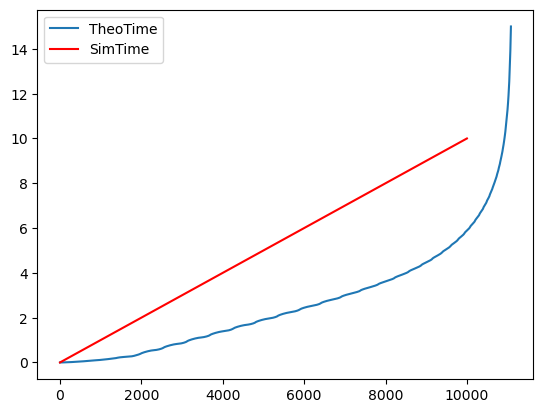

KeyboardInterrupt: 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 创建图形和三维轴
sim_data = np.load("./data/Exp-10N Force Pulse-20241223_223953/StaticState_list.npy")

t = scipy.io.loadmat("./AtoBMatlab/t.mat")['t']
theta_1 = scipy.io.loadmat("./AtoBMatlab/theta_1.mat")['theta_1']
theta_2 = scipy.io.loadmat("./AtoBMatlab/theta_2.mat")['theta_2']


# 时间并没有对齐
plt.plot(t, label="TheoTime")
plt.plot(sim_data[:,2]-10, 'r', label="SimTime")
plt.legend()
plt.show()

plt.plot(sim_data[:,2]-10, sim_data[:,3]+math.pi/2, label="theta1_sim")
plt.plot(sim_data[:,2]-10, sim_data[:,4], label="theta2_sim")
plt.plot(t, theta_1, label="theta1_theo")
plt.plot(t, theta_2, label="theta2_theo")
plt.legend()
plt.xlabel("time/s")
plt.ylabel("angle/rad")
plt.xlim([0, 3])
plt.ylim([0, 1.62])


# cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
t_intervel = np.linspace(0, 3, 300)
theta1_sim_intervel = np.interp(t_intervel, sim_data[:,2]-10, sim_data[:,3]+math.pi/2)
theta2_sim_intervel = np.interp(t_intervel, sim_data[:,2]-10, sim_data[:,4])
theta1_theo_intervel = np.interp(t_intervel, t.flatten(), theta_1.flatten())
theta2_theo_intervel = np.interp(t_intervel, t.flatten(), theta_2.flatten())

mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel))
mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel))
maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))


plt.text(2, 1.4, f"MSE_theta_1[0-3s]={round(mse_theta1, 6)}rad^2")
plt.text(2, 1.3, f"MaxError_theta_1[0-3s]={round(maxerror_theta1, 6)}rad")
plt.text(2, 0.6, f"MSE_theta_2[0-3s]={round(mse_theta2, 6)}rad^2")
plt.text(2, 0.5, f"MaxError_theta_2[0-3s]={round(maxerror_theta2, 6)}rad")


plt.title("Dynamic Test\n-Force Impulse(10N, 10N) at Static State(pi/2, 0)")

plt.show()

